In [11]:
pip install datasets

In [12]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [14]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [15]:
import pandas as pd

df = dataset["train"].to_pandas()
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [16]:
print(df.columns)
print(df.shape)

Index(['text', 'label'], dtype='object')
(16000, 2)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train)

pred = model.predict(X_test_vec)

print("Accuracy =", accuracy_score(y_test, pred))

Accuracy = 0.84125


In [19]:
text = ["I am feeling very happy today"]
vec = vectorizer.transform(text)
print(model.predict(vec))

[1]


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.84125
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       946
           1       0.79      0.97      0.87      1021
           2       0.89      0.55      0.68       296
           3       0.90      0.77      0.83       427
           4       0.85      0.70      0.77       397
           5       0.88      0.43      0.58       113

    accuracy                           0.84      3200
   macro avg       0.86      0.73      0.77      3200
weighted avg       0.85      0.84      0.83      3200



In [21]:
text = ["I am very excited today"]
vec = vectorizer.transform(text)
result = model.predict(vec)
print(result)

[1]


In [22]:
labels = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

text = ["I am very excited today"]
vec = vectorizer.transform(text)
result = model.predict(vec)[0]

print("Predicted Emotion:", labels[result])

Predicted Emotion: joy


In [24]:
text = ["I miss my best friend so much"]

In [25]:
text = ["I am scared of exam result"]

In [27]:
text = ["Why did you lie to me? I am angry"]

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3
(16000, 2)
            Model Name  Accuracy (%)
2                  SVM         88.84
3        Random Forest         85.34
0  Logistic Regression         84.12
4                  KNN         70.59
1          Naive Bayes         61.75


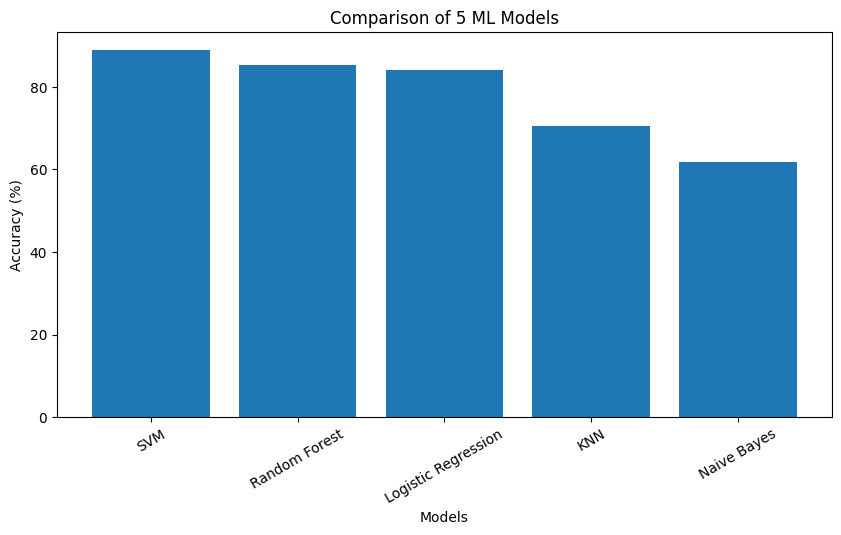

Best Model = SVM
Predicted Emotion = joy
Predicted Emotion = fear


In [29]:
# ==========================================
# STEP 1 : Import Libraries
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


# ==========================================
# STEP 2 : Load Dataset
# ==========================================

dataset = load_dataset("dair-ai/emotion")
df = dataset["train"].to_pandas()

print(df.head())
print(df.shape)


# ==========================================
# STEP 3 : Input and Output
# ==========================================

X = df["text"]
y = df["label"]


# ==========================================
# STEP 4 : Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==========================================
# STEP 5 : Convert Text into Numbers
# ==========================================

vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


# ==========================================
# STEP 6 : Apply 5 Models
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():

    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, pred) * 100

    results.append([name, round(acc,2)])


# ==========================================
# STEP 7 : Comparison Table
# ==========================================

result_df = pd.DataFrame(results, columns=["Model Name", "Accuracy (%)"])
result_df = result_df.sort_values(by="Accuracy (%)", ascending=False)

print(result_df)


# ==========================================
# STEP 8 : Graph Comparison
# ==========================================

plt.figure(figsize=(10,5))
plt.bar(result_df["Model Name"], result_df["Accuracy (%)"])
plt.title("Comparison of 5 ML Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()


# ==========================================
# STEP 9 : Best Model
# ==========================================

best_model_name = result_df.iloc[0,0]

print("Best Model =", best_model_name)

best_model = models[best_model_name]


# ==========================================
# STEP 10 : Save Model
# ==========================================

joblib.dump(best_model, "best_emotion_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")


# ==========================================
# STEP 11 : Predict Custom Input
# ==========================================

labels = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

text = ["I am very happy today"]

vec = vectorizer.transform(text)

prediction = best_model.predict(vec)[0]

print("Predicted Emotion =", labels[prediction])


# ==========================================
# STEP 12 : Load Saved Model Again
# ==========================================

loaded_model = joblib.load("best_emotion_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

text2 = ["I am scared of exam result"]

vec2 = loaded_vectorizer.transform(text2)

pred2 = loaded_model.predict(vec2)[0]

print("Predicted Emotion =", labels[pred2])

In [30]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

pred = svm_model.predict(X_test_vec)

from sklearn.metrics import accuracy_score
print("SVM Accuracy =", accuracy_score(y_test, pred)*100)

SVM Accuracy = 88.84375


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       946
           1       0.88      0.94      0.91      1021
           2       0.81      0.73      0.77       296
           3       0.90      0.89      0.89       427
           4       0.85      0.84      0.85       397
           5       0.88      0.68      0.77       113

    accuracy                           0.89      3200
   macro avg       0.87      0.83      0.85      3200
weighted avg       0.89      0.89      0.89      3200



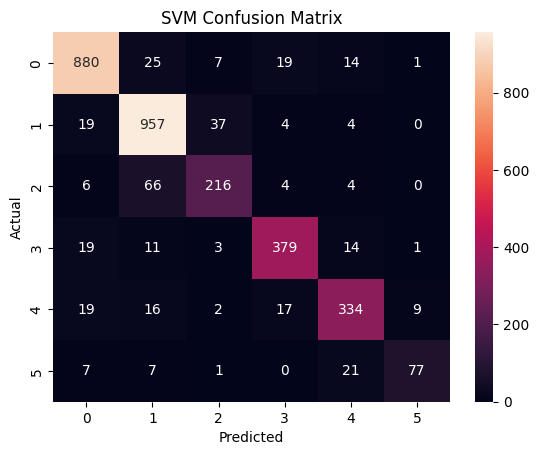

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
import joblib

joblib.dump(svm_model, "svm_emotion_model.pkl")

['svm_emotion_model.pkl']

In [34]:
text = ["I feel nervous about tomorrow"]
vec = vectorizer.transform(text)
print(svm_model.predict(vec))

[4]
